# Time series analysis
---

Running this notebook you will:

- Plot the timeseries
- Extract the features
- Plot the univarialte and bivariate relation between the features

In [1]:
#@markdown ###Run this cell to connect your Google Drive to Colab and install packages

#@markdown After the first execution you might receive some warning and notifications, please follow these instructions:

#@markdown * Warning: This notebook was not authored by Google. Click on *'Run anyway'*.
#@markdown * Permit this notebook to access your Google Drive files? Click on *'Yes'*, and select your account.
#@markdown * Google Drive for desktop wants to access your Google Account. Click on *'Allow'*.

# Mounts user's Google Drive to Google Colab switch folder.
from google.colab import drive
drive.mount('/content/gdrive')
#%cd /content/gdrive/MyDrive/
#!git clone https://github.com/HelmholtzAI-Consultants-Munich/NMOs-Contraction.git
%cd /content/gdrive/MyDrive/NMO-colab/

# Install necessary packages
%pip install tsfresh
%pip install -U kaleido

Mounted at /content/gdrive
/content/gdrive/MyDrive/NMO-colab
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.2/136.2 kB 13.8 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.5 MB/s eta 0:00:00


In [13]:
#@markdown ## Import
#@markdown Run the next cell to import the necessary packages

import glob
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline  
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import kaleido
# from IPython.display import Markdown as md
import ipywidgets as widgets
from IPython.display import display
from IPython.display import display_markdown
from utils.pre_processing import process_single_ts
from utils.feature_extraction import create_feature_in_dataframe
from utils.plot_boxplot import plot_box_plots

In [3]:
#@markdown ## Custom data path

#@markdown In case you will change the folder structure, you can insert here the paths to the data (extracted time series) and the figures.

data_path = 'extracted_signals' #@param {type:"string"}
figure_path = 'figures' #@param {type:"string"}
figure_path = figure_path + '/'

In [4]:
#@markdown ## Pre-processing
#@markdown Running this cell the you will open the time series and the info file data, and pre-process the time series.

#@markdown The pre-processing consist of the following steps:
#@markdown - polynomial interpolation in case missing values are present
#@markdown - de-trending
#@markdown - smoothing
#@markdown - scaling: pixel in micrometer and bin in seconds

#@markdown  If you want to print the complete list of all the processed data check the box below.

# Open data info file
data_info = pd.read_excel('Contraction_videos_legend.xlsx')
# Rename columns and fill NA values
data_info.rename(columns={'File_video name': 'Filename'}, inplace=True)
data_info['Treatment during contraction'].fillna('Other', inplace=True)

# Open time series files
filename_list = []
data = []
files = []

for filename in glob.glob(os.path.join(data_path, '*.npy')):
    filename_list.append(Path(filename).stem)
    with open(filename, 'r') as f:
        data.append([Path(filename).stem, np.load(filename)])

print_filenames = False #@param {type:"boolean"}
if print_filenames:
  for index, name in enumerate(filename_list):
     print(index, name)     

# Delete tail corrupted data
if 'O1318_1b' in filename_list:
  element = 'O1318_1b'
  print(f'The tale of {element} has been cut beacuse the data were currupted.')
  index = filename_list.index(element)
  data[index][1] = data[index][1][:, :650]

# Pre-processing
data_processed = []

for data_i in data:
  data_processed_i, is_nan_flag = process_single_ts(data_i[1], smooth=True, de_trend=True)
  data_processed.append([data_i[0], data_processed_i])
  if is_nan_flag:
    print(f'The signal {data_i[0]} has NaNs and the missing values have been interpolated')

print(f'Number of processed files: {len(filename_list)}')

The tale of O1318_1b has been cut beacuse the data were currupted.
The signal O4979_1a has NaNs and the missing values have been interpolated
Number of processed files: 68


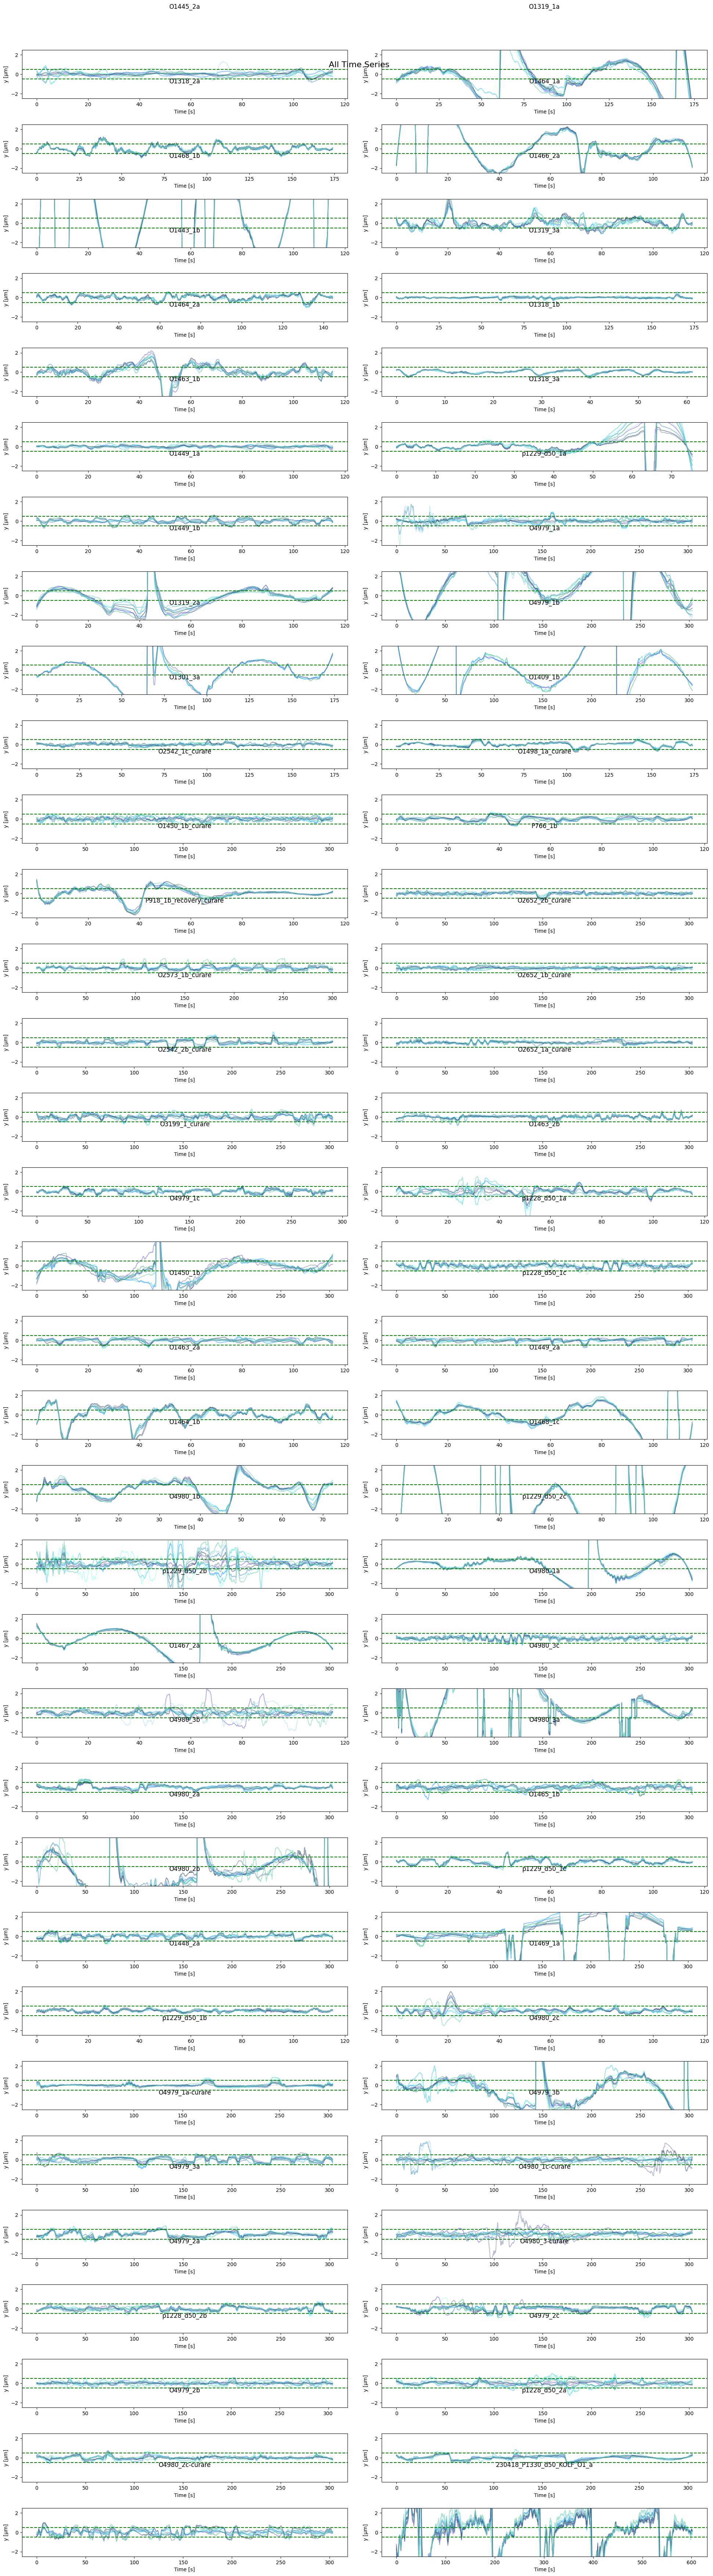

In [5]:
#@markdown ## Plot all time series
#@markdown Run this cell to visualize all the time series after the pre-processing step
#@markdown The plots will be saved in the figure folder (in a unique file called 'All Time Series' and also in multiple small windows for a better visualization.

#@markdown Here you can choose where to set the value for the horizontal dashed line to help you visualizing the different time series

line_of_reference = 0.5 #@param {type:"number"}
t_weak = line_of_reference
t_conversion = 0.097
plot_info = {'y_min': -2.5,
             'y_max': 2.5,
             'subplot_layout_row': 34, 
             'subplot_layout_col': 2, 
             'title': 'All Time Series'}

colors = ["#43C6DB", "#93FFE8", "dodgerblue", "mediumseagreen", "slateblue", "#737CA1", "#29465B", "#368BC1",
          "#AFDCEC", "#66CDAA"]

fig, axis = plt.subplots(plot_info['subplot_layout_row'], plot_info['subplot_layout_col'], figsize=(20, 70))
fig.suptitle(plot_info['title'], fontsize=16)
plt.tight_layout(pad=3.)
for ax, data_i in zip(axis.flat, data_processed):
    for i in range(data_i[1].shape[0]):
        ax.plot([t * t_conversion for t in range(len(data_i[1][i, :]))], data_i[1][i, :], color=colors[i], alpha=0.5)
    ax.set_title(data_i[0], y=2., pad=-14)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('y [\u03BCm]')
    ax.set_ylim(plot_info['y_min'], plot_info['y_max'])
    ax.axhline(y=t_weak, color='g', linestyle='--', label='std')
    ax.axhline(y=-t_weak, color='g', linestyle='--', label='std')
fig.savefig(figure_path + plot_info['title'])
# plot_all_signals = True #@param {type:"boolean"}
# if plot_all_signals == False: 
#   plt.close()

# Save figures in different files 
plot_info = {'y_min': -2.5,
             'y_max': 2.5,
             'subplot_layout_row': 5,
             'subplot_layout_col': 2,
             'title': 'Time series - window '}
number_of_windows = 7
ind_start = 0
incr = plot_info['subplot_layout_row'] * plot_info['subplot_layout_col']
ind_stop = incr
for window_n in range(number_of_windows):
    fig, axis = plt.subplots(plot_info['subplot_layout_row'], plot_info['subplot_layout_col'], figsize=(15, 10))
    fig.suptitle(plot_info['title'] + str(window_n + 1), fontsize=16, y=0.98)
    plt.tight_layout(pad=3.)
    for ax, data_i in zip(axis.flat, data_processed[ind_start:ind_stop]):
        for i in range(data_i[1].shape[0]):
            ax.plot([t * t_conversion for t in range(len(data_i[1][i, :]))], data_i[1][i, :],
                    color=colors[i], alpha=0.5)
        ax.set_title(data_i[0], y=1.5, pad=-14)
        ax.set_xlabel('Time [s]')
        ax.set_ylabel('y [\u03BCm]')
        ax.set_ylim(plot_info['y_min'], plot_info['y_max'])
        ax.axhline(y=t_weak, color='g', linestyle='--', label='std')
        ax.axhline(y=-t_weak, color='g', linestyle='--', label='std')
    ind_start = ind_stop
    ind_stop += incr
    fig.savefig(figure_path + plot_info['title'] + str(window_n + 1))
    plt.close(fig)


In [5]:
#@markdown ### Plot a specific time series
t_conversion = 0.097
#@markdown If you want to focus only on specific signals and compare them, check the following box and enter the names of the signals you are interested in.
#@markdown You can visualize up to 4 signals at the same time, customize the rows and colums.

signal_1 = 'O4980_2a' #@param {type:"string"}
signal_2 = 'O1319_1a' #@param {type:"string"}
signal_3 = 'O1449_1a' #@param {type:"string"}
signal_4 = 'O1449_1a' #@param {type:"string"}

rows = 4 #@param {type:"integer"}
columns = 2 #@param {type:"integer"}

plot_info = {'y_min': -2.5,
             'y_max': 2.5,
             'subplot_layout_row': 34, 
             'subplot_layout_col': 2, 
             'title': 'All Time Series'}
colors = ["#43C6DB", "#93FFE8", "dodgerblue", "mediumseagreen", "slateblue", "#737CA1", "#29465B", "#368BC1",
          "#AFDCEC", "#66CDAA"]
signal_list = [signal_1, signal_2, signal_3, signal_4]
signal_list_plot = [s for s in signal_list if s]
ind_list = [filename_list.index(s) for s in signal_list_plot]
data_processed_plot = [data_processed[ind] for ind in ind_list]
ind_plot = rows * columns
data_processed_plot = data_processed_plot[:(ind_plot)]

#@markdown If you want to save the figure, check the following box insert, and choose a name. 
#@markdown The figure in png and html formats will be saved in the 'figures' folder.
#@markdown (The html formal allows you to have an interactive figure. To open it you have to download it first, then double click on the file and a window with the figure will open in your browser).
save = False #@param {type:"boolean"}
plot_title = '' #@param {type:"string"}
fig_new = make_subplots(rows=rows, cols=columns, subplot_titles=signal_list)
r = 0
c = 0
for i in range(len(data_processed_plot)): #len(data_processed)):
  
  fig_ = px.line(x=[t * t_conversion for t in range(len(data_processed_plot[i][1][0]))], y=[data_i for data_i in data_processed_plot[i][1]], color_discrete_sequence=colors,
                  range_y=[plot_info['y_min'], plot_info['y_max']])
  fig_.update_layout(showlegend=False)
  fig_.update_traces(opacity=0.5)

  if columns == 1:
    c = 1
    r += 1
  elif rows == 1:
    r = 1
    c += 1
  else:
    if c == 2:
      if r == 0:
        r = 1
      r +=1
      c = 1
    else:
      if r == 0:
        r = 1
      c +=1

  for trace in fig_["data"]:
    fig_new.add_trace(trace, row=r, col=c)
    fig_new.update_xaxes(title_text='Time [s]', row=r, col=c)
    fig_new.update_yaxes(title_text='y [\u03BCm]', row=r, col=c, range=[plot_info['y_min'], plot_info['y_max']])
fig_new.update_layout(height=800, width=1500)
fig_new.update_layout(showlegend=False)

if save:
  if plot_title == '':
    print('Attention! If you want to save the figure, please choose a name, and execute the cell!')
  else:
    fig_new.write_html(figure_path + plot_title + ".html")
    fig_new.write_image(figure_path + plot_title + ".png", format='png')
fig_new.show()

In [6]:
#@markdown ## Create DataFrame with extracted features and data info
#@markdown Running this cell you will extract the features and create a table with all the data info and the extracted features.

#@markdown - Energy
#@markdown - Mean
#@markdown - Percentage of Count Above Threshold
#@markdown - Percentage of Absolute Sum of Changes
#@markdown - 75 Quantile
#@markdown - Standard Deviazion

#@markdown Here you can set the threshold for the feature *Percentage of Count Above Threshold*. The default value is 0.5.
threshold = 0.5 #@param 
# Feature extraction
df_data = create_feature_in_dataframe(data_processed, threshold)

# Before the merge, rename the files to eliminate the extension and match the filenames between the two dataframes
data_info['Filename'] = data_info['Filename'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
df_data_final = pd.merge(df_data, data_info, on='Filename')

df_data_final

,Filename,Energy,Mean,%_of_count_above_threshold,%_of_absolute_sum_of_changes,Quantile_75,Standard_deviation,%_of_count_above_mean,Experiment (plate),Cell line,Phenotype,Treatment during contraction,Day,USER,User classification,Sent,Comments,Threshold
0,O1445_2a,0.494167,0.001553,0.019344,0.012509,0.091639,0.218823,0.542893,P426,SMAE1C4,Disease,None,60,AGP,No contraction,2022-05-16,NaN,default
1,O1319_1a,70.826850,0.025057,0.299610,0.062016,0.623074,2.617394,0.469621,P427,H1,Control,None,60,AGP,Strong contraction,2022-05-10,NaN,default
2,O1318_2a,1.313557,0.001413,0.070792,0.027876,0.224592,0.356947,0.491639,P426,SMAE1C4,Disease,None,60,AGP,Weak contraction,2022-05-10,NaN,default
3,O1464_1a,208.187278,0.035326,0.437763,0.096431,1.503946,4.493569,0.519765,P482,SMAE1C4+DOX,Recovery,None,50,AGP,Strong contraction,2022-05-10,NaN,default
4,O1468_1b,1648.618763,-0.007170,0.517241,0.498456,7.451611,12.645776,0.533221,P487,SMAE1C4+DOX,Recovery,None,50,AGP,Strong contraction,2022-05-10,NaN,default
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,p1228_d50_2b,0.514297,0.000380,0.016083,0.007837,0.154671,0.222649,0.496019,P1228,H1,Control,Other,50,CB,NaN,2022-12-05,O4882,default
63,O4979_2c,1.395115,-0.001946,0.099425,0.012318,0.237232,0.364986,0.512948,P1263,H1 (LDN),Control,Other,50,CB,NaN,2022-12-05,NaN,default
64,O4979_2b,0.514565,0.000107,0.033088,0.007377,0.140999,0.220994,0.454284,P1263,H1 (LDN),Control,Other,50,CB,NaN,2022-12-05,NaN,default
65,p1228_d50_2a,0.569267,-0.001875,0.029777,0.006536,0.135267,0.229818,0.485669,P1228,H1,Control,Other,50,CB,NaN,2022-12-05,O4882,default


## Univariate analysis

In [11]:
#@markdown Choose the feature for the classification and plot the boxplot for the different variables.
fig_uni_variate = make_subplots(rows=2, cols=3)
ax_list = [[1, 1], [1, 2], [1, 3], [2, 1], [2, 2], [2, 3]]
ind = 0

x_boxplot = 'Treatment during contraction' #@param ['Treatment during contraction', 'Phenotype']

#@markdown The figure will be automatically saved in the 'figures' folder.

for ax, col in zip(ax_list, list(df_data_final.columns)[1:7]):
    fig_ = px.box(df_data_final, x=x_boxplot, y=col, color=x_boxplot)# , points="outliers") # Options: None, all, ouliers, suspectedoutliers")
    for trace in fig_["data"]:
        trace.legendgroup = trace.name
        fig_uni_variate.add_trace(trace, row=ax[0], col=ax[1])
        if ind != 0:
            fig_uni_variate.data[-1].showlegend = False

    if col == 'Energy':
        units = 'Normalized Energy [\u03BCm^2 / s]'
    elif col in ['Standard_deviation', 'Mean', 'Quantile_75']:
        units = col + ' [\u03BCm]'
    else:
        units = col
    fig_uni_variate.update_layout(height=800, width=1500)
    fig_uni_variate.update_xaxes(title_text=x_boxplot, row=ax[0], col=ax[1])
    fig_uni_variate.update_yaxes(title_text=units, row=ax[0], col=ax[1])
    ind += 1

fig_uni_variate.show()
fig_uni_variate.write_html(figure_path + "Univariate - " + x_boxplot +".html")
fig_uni_variate.write_image(figure_path + "Univariate - " + x_boxplot + ".png", format='png')


## Bi-variate analysis

In [10]:
#@markdown ## Customize the plot
#@markdown Run the cell and then choose the colors and markers for the plots.
display_markdown(''' Select a color for each **Treatment**:''', raw=True)
categories_treatment = df_data_final['Treatment during contraction'].unique()
default_color = 'blue'
dict_colors = {}

def update_color(change):
    category = change.owner.description[:-9]
    new_color = change.new if change.new else default_color
    dict_colors[category] = new_color

for c in categories_treatment:
    w = widgets.ColorPicker(
        concise=False,
        description=str(c) + ' category',
        value=default_color,
        disabled=False
    )
    w.observe(update_color, names='value')
    display(w)
    
    # Check if category already exists in dictionary
    if c not in dict_colors:
        dict_colors[c] = default_color

display_markdown(''' Select a marker for each **Phenotype**:''', raw=True)
categories_phenotype = df_data_final['Phenotype'].unique()
default_marker = 'circle'
dict_markers = {}

def update_marker(change):
    category = change.owner.description[:-9]
    new_marker = change.new
    dict_markers[category] = new_marker

for c in categories_phenotype:
    w = widgets.Dropdown(
        options=['circle', 'diamond', 'cross', 'square', 'circle-open', 'square-open'],
        description=str(c) + ' category',
        value=default_marker,
        disabled=False
    )
    w.observe(update_marker, names='value')
    display(w)

  # Check if category already exists in dictionary
    if c not in dict_markers:
      dict_markers[c] = default_marker

 Select a color for each **Treatment**:

ColorPicker(value='blue', description='None category')

ColorPicker(value='blue', description='Other category')

ColorPicker(value='blue', description='Curare category')

 Select a marker for each **Phenotype**:

Dropdown(description='Disease category', options=('circle', 'diamond', 'cross', 'square', 'circle-open', 'squa…

Dropdown(description='Control category', options=('circle', 'diamond', 'cross', 'square', 'circle-open', 'squa…

Dropdown(description='Recovery category', options=('circle', 'diamond', 'cross', 'square', 'circle-open', 'squ…

Dropdown(description='Disease II category', options=('circle', 'diamond', 'cross', 'square', 'circle-open', 's…

In [15]:
#@markdown ## Create bivariate plot
#@markdown Run thi cell to create the plots and save them directly in the figures folder
var_plot = [
    ['Energy', '%_of_absolute_sum_of_changes', 1, 1],
    ['Energy', 'Quantile_75', 1, 2],
    ['%_of_count_above_threshold', '%_of_absolute_sum_of_changes', 1, 3],
    ['%_of_absolute_sum_of_changes', 'Quantile_75', 2, 1],
    ['%_of_absolute_sum_of_changes', 'Standard_deviation', 2, 2],
    ['Quantile_75', 'Standard_deviation', 2, 3]
]

fig_final = make_subplots(rows=2, cols=3)

ind = 0
unique_legends = set()

for x, y, r, c in var_plot:
    fig_ = px.scatter(df_data_final, x=x, y=y,
                      color='Treatment during contraction',
                      color_discrete_map=dict_colors,
                      symbol='Phenotype',
                      hover_name='Filename'
                      )

    for trace in fig_.data:
        phenotype = trace.name
        marker_symbol = dict_markers.get(phenotype.split(',')[1][1:], 'circle')
        legend_name = f"{phenotype.split(',')[1][1:]} - {trace.hovertext[0]}"
        treatment = trace.hovertext[0]
        color= dict_colors.get(phenotype.split(',')[0])

        if legend_name not in unique_legends:
            fig_final.add_trace(
                go.Scatter(
                    x=trace.x,
                    y=trace.y,
                    mode=trace.mode,
                    name=trace.name,
                    legendgroup=trace.legendgroup,
                    marker=dict(symbol=marker_symbol, color=color),  # Assign color based on treatment
                    hovertext=trace.hovertext
                ),
                row=r, col=c
            )
            unique_legends.add(legend_name)
        else:
            fig_final.add_trace(
                go.Scatter(
                    x=trace.x,
                    y=trace.y,
                    mode=trace.mode,
                    name=trace.name,
                    legendgroup=trace.legendgroup,
                    showlegend=False,
                    marker=dict(symbol=marker_symbol, color=color),  # Assign color based on treatment
                    hovertext=trace.hovertext
                ),
                row=r, col=c
            )

    fig_final.update_xaxes(title_text=x, row=r, col=c)
    fig_final.update_yaxes(title_text=y, row=r, col=c)

fig_final.update_layout(height=800, width=1500)
fig_final.write_html(figure_path + "Bivariate.html")
fig_final.write_image(figure_path + "Bivariate.png")
fig_final.show()

In [16]:
x#@markdown ## Focus on one plot
#@markdown Choose the quantities that you want to plot to have an interactive plot where you can zoom in and out and change colors figure you want to analyse better

x = '%_of_count_above_threshold' #@param ["Energy", "%_of_absolute_sum_of_changes", "%_of_count_above_threshold", "Quantile_75", "Standard_deviation"]
y = '%_of_absolute_sum_of_changes' #@param ["Energy", "%_of_absolute_sum_of_changes", "%_of_count_above_threshold", "Quantile_75", "Standard_deviation"]

fig = px.scatter(df_data_final, x=x, y=y,
                 color='Treatment during contraction',
                 color_discrete_map=dict_colors,
                 symbol='Phenotype',
                 hover_name='Filename'
                 )

unique_legends = set()

for trace in fig.data:
    phenotype = trace.name
    marker_symbol = dict_markers.get(phenotype.split(',')[1][1:], 'circle')
    legend_name = f"{phenotype.split(',')[1][1:]} - {trace.hovertext[0]}"
    treatment = trace.hovertext[0]
    color = dict_colors.get(phenotype.split(',')[0])

    if legend_name not in unique_legends:
        fig.update_traces(
            marker=dict(symbol=marker_symbol, color=color),  # Assign marker and color based on treatment
            selector=dict(name=trace.name)
        )
        unique_legends.add(legend_name)
    else:
        fig.update_traces(
            showlegend=False,
            marker=dict(symbol=marker_symbol, color=color),  # Assign marker and color based on treatment
            selector=dict(name=trace.name)
        )

fig.update_layout(height=800, width=1500)
fig.write_html(figure_path + "Bivariate.html")
fig.write_image(figure_path + "Bivariate.png")

marker_size = 7 #@param {type:"slider", min:1, max:10, step:1} 
fig.update_traces(marker_size=marker_size)

#@markdown If you want to save the figure, check the following box insert, and choose a name. 
save = False #@param {type:"boolean"}
figure_name = "Plot_1" #@param {type:"string"}
if save:
  if figure_name == '':
    print('Attention! If you want to save the figure, please choose a name, and execute the cell!')
  else:
    fig.write_image(figure_path + figure_name + ".png")
    fig.write_html(figure_path + figure_name + ".html")
fig.show()

---